   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=RetinaNet_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth
100%|██████████| 130M/130M [00:01<00:00, 86.2MB/s]


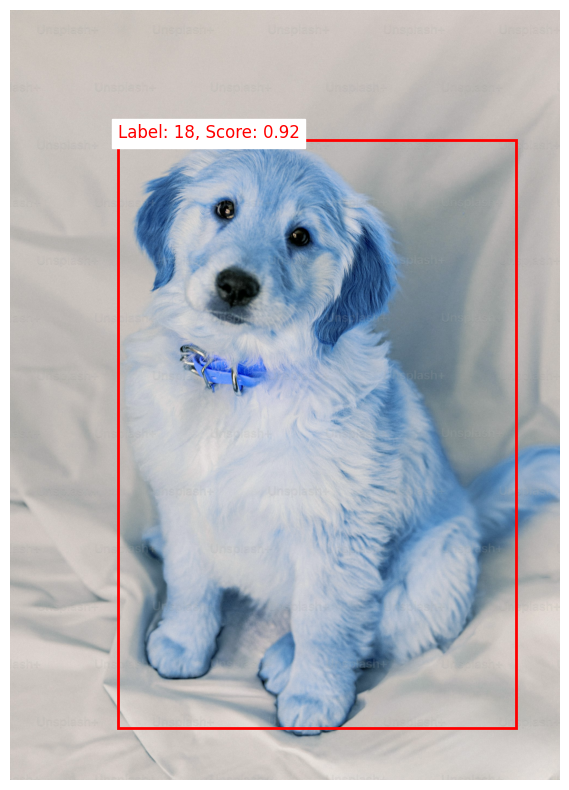

In [ ]:
# Step 1: Install required libraries (if not already installed)
!pip install torch torchvision opencv-python matplotlib requests

# Step 2: Import libraries
import torch
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.transforms import functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
import io

# Step 3: Load a pre-trained RetinaNet model
model = retinanet_resnet50_fpn(pretrained=True)
model.eval()  # Set the model to evaluation mode

# Step 4: Load and preprocess the image from a URL
def load_image_from_url(url):
    # Download the image using requests
    response = requests.get(url)
    if response.status_code != 200:
        raise ValueError(f"Failed to download image from {url}. Status code: {response.status_code}")

    # Convert the image to a numpy array
    image = np.array(Image.open(io.BytesIO(response.content)))

    # Convert the image to RGB (if it has an alpha channel)
    if image.shape[-1] == 4:
        image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)
    else:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert the image to a tensor
    image = F.to_tensor(image)
    return image

# Step 5: Perform object detection
def detect_objects(image_tensor, confidence_threshold=0.5):
    # Add a batch dimension (required by the model)
    image_tensor = image_tensor.unsqueeze(0)

    # Perform inference
    with torch.no_grad():
        predictions = model(image_tensor)

    # Extract predictions
    boxes = predictions[0]['boxes']
    labels = predictions[0]['labels']
    scores = predictions[0]['scores']

    # Filter predictions based on confidence threshold
    keep = scores > confidence_threshold
    boxes = boxes[keep]
    labels = labels[keep]
    scores = scores[keep]

    return boxes, labels, scores

# Step 6: Visualize the results
def plot_detections(image, boxes, labels, scores):
    # Convert the image tensor to a numpy array for visualization
    image = image.permute(1, 2, 0).cpu().numpy()

    # Plot the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    # Draw bounding boxes and labels
    for box, label, score in zip(boxes, labels, scores):
        box = box.cpu().numpy().astype(int)
        label = label.cpu().numpy()
        score = score.cpu().numpy()

        # Draw rectangle
        plt.gca().add_patch(plt.Rectangle(
            (box[0], box[1]), box[2] - box[0], box[3] - box[1],
            edgecolor='red', facecolor='none', linewidth=2
        ))

        # Add label and score
        plt.text(
            box[0], box[1] - 5, f'Label: {label}, Score: {score:.2f}',
            color='red', fontsize=12, backgroundcolor='white'
        )

    plt.axis('off')
    plt.show()

# Step 7: Run the detection on an example image from a URL
# Provide the image URL
image_url = "https://plus.unsplash.com/premium_photo-1694819488591-a43907d1c5cc?q=80&w=2028&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

# Load the image from the URL
image_tensor = load_image_from_url(image_url)

# Detect objects
boxes, labels, scores = detect_objects(image_tensor)

# Visualize the results
plot_detections(image_tensor, boxes, labels, scores)

In [6]:
pip install torch torchvision pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [8]:
from torchvision import transforms

class ComposeTransform:
    def __init__(self):
        self.transforms = transforms.Compose([
            transforms.ToTensor(),  # Converts PIL image to FloatTensor and scales values [0,1]
        ])

    def __call__(self, image, target):
        image = self.transforms(image)
        return image, target


In [9]:
import torchvision.transforms.v2 as T

In [10]:
from torchvision import transforms

In [14]:
import torch
import torchvision
from torchvision.datasets import CocoDetection
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import os

# --- Define Transform ---
class ComposeTransform:
    def __init__(self):
        self.transforms = ToTensor()

    def __call__(self, image, target):
        image = self.transforms(image)
        return image, target

# --- Paths to COCO data ---
rroot = 'https://drive.google.com/drive/folders/15L1kH1AWHM_1LocWdEtfWcdyTxuKdBi7?usp=drive_link'
annFile = 'https://drive.google.com/file/d/13J85bhIwAq83hIOJDsV8U0E01pWeK7nE/view?usp=drive_link'
# --- Dataset and DataLoader ---
dataset = CocoDetection(root=root, annFile=annFile, transform=ComposeTransform())
data_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# --- Model ---
model = retinanet_resnet50_fpn(pretrained=True)
model.train()

# --- Move to GPU if available ---
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# --- Optimizer ---
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# --- Training Loop ---
num_epochs = 2
for epoch in range(num_epochs):
    for images, targets in data_loader:
        images = list(img.to(device) for img in images)
        targets = [
            {
                'boxes': torch.tensor([obj['bbox'] for obj in target], dtype=torch.float32).to(device),
                'labels': torch.tensor([obj['category_id'] for obj in target], dtype=torch.int64).to(device)
            }
            for target in targets
        ]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {losses.item():.4f}")


loading annotations into memory...


FileNotFoundError: [Errno 2] No such file or directory: 'https://drive.google.com/file/d/13J85bhIwAq83hIOJDsV8U0E01pWeK7nE/view?usp=drive_link'

In [11]:
import torch
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.datasets import CocoDetection
from torchvision import transforms
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as T
import os
import numpy as np
from PIL import Image
import torchvision

# Custom Transform
class ComposeTransform:
    def __init__(self):
        self.transforms = T.Compose([
            T.ToImageTensor(),
            T.ConvertImageDtype(torch.float),
        ])

    def __call__(self, image, target):
        image = self.transforms(image)
        return image, target

# Dataset Paths
root = 'https://drive.google.com/drive/u/1/folders/15L1kH1AWHM_1LocWdEtfWcdyTxuKdBi7g'
annFile = 'https://drive.google.com/drive/u/1/folders/1YEhSQzqHqSbm6hA8KyzhoAHLJXLc_fQK/coco_train.json'

# Dataset and DataLoader
dataset = CocoDetection(root=root, annFile=annFile, transform=ComposeTransform())
data_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Load RetinaNet
model = retinanet_resnet50_fpn(pretrained=False, num_classes=2)  # 80 COCO classes + background

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# Training Loop (simplified for 1 epoch)
model.train()
for images, targets in data_loader:
    images = list(img.to(device) for img in images)

    new_targets = []
    for t in targets:
        boxes = []
        labels = []
        for obj in t:
            boxes.append(obj['bbox'])  # [x, y, w, h]
            labels.append(obj['category_id'])
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        boxes[:, 2:] += boxes[:, :2]  # Convert to [x1, y1, x2, y2]
        new_targets.append({'boxes': boxes, 'labels': labels})

    targets = [{k: v.to(device) for k, v in t.items()} for t in new_targets]

    loss_dict = model(images, targets)
    losses = sum(loss for loss in loss_dict.values())

    optimizer.zero_grad()
    losses.backward()
    optimizer.step()

    print(f"Loss: {losses.item():.4f}")


AttributeError: module 'torchvision.transforms.v2' has no attribute 'ToImageTensor'